# Fractional Brownian Motion Parameter Estimation Using Periodogram Method

The periodigram method uses the fractional brownian noise power spectrum to estimate the Hurst, denoted by $H$. The power spectrum is the Fourier transform of the fractional brownian motion noise autocorrelation function. This relationship is called the Weiner-Khichnin theorem.</br>

Let $Z^H(t)$ denote a fractional path then fractional brownian noise is defined by,

$
\begin{align}
\Delta Z_k^H = Z^H(t_k) - Z^H(t_{k-1})
\end{align}
\tag{1}
$

where $t_k = k \Delta t$. It follows that,

$
\begin{align}
Z^H(n\Delta t) = \sum_{i=1}^n \Delta Z_k^H
\end{align}
\tag{2}
$

The autocovariance of fractional brownian noise is given by,

$
\begin{align}
\gamma^H_n = \text{Cov}[\Delta Z^H_t \Delta Z^H_{t+n}] = \frac{1}{2}\Delta t^{2H}[(n-1)^{2H} + (n+1)^{2H} - 2n^{2H}]
\end{align}
\tag{3}
$

Since $\text{Var}(\Delta Z_k^H) = \Delta t^{2H}$ the autocorrelation coefficient is defined by,</br>

$
\begin{align}
\rho^H_n = \frac{\gamma^H_n}{\Delta t^{2H}} = \frac{1}{2}[(n-1)^{2H} + (n+1)^{2H} - 2n^{2H}]
\end{align}
\tag{4}
$

From the Weiner-Khichnin theorem the power spectrum is given by,</br>

$
\begin{align}
\hat{\rho}^H_\omega = \frac{1}{2} \int_{-\infty}^{\infty} \rho^H_n e^{-i \omega n} dn
\end{align}
\tag{5}
$

It can be shown that fir $\omega \gg 1$,

$
\begin{align}
\hat{\rho}^H_\omega \approx C\lvert \omega \rvert^{1 - 2H}
\end{align}
\tag{6}
$

where $C$ is independent of $\omega$. It follows that $H$ can be determined by using OLS on $\hat{\rho}^H_\omega$ as a< function of $\omega$.

## Imports

In [3]:
%reload_ext autoreload
%autoreload 2

# import system modules and set local import path
import os
import sys
from matplotlib import pyplot

sys.path.insert(0, os.path.abspath('../../..'))

# import local modules
from lib import config
from lib.data import fbm, stats
from lib.plots import periodogram, curve, PlotType

# Config Plot Style
pyplot.style.use(config.glyfish_style)

## Helpers

In [4]:
npts = 2**10

## Power Spectrum Simulation H=0.8

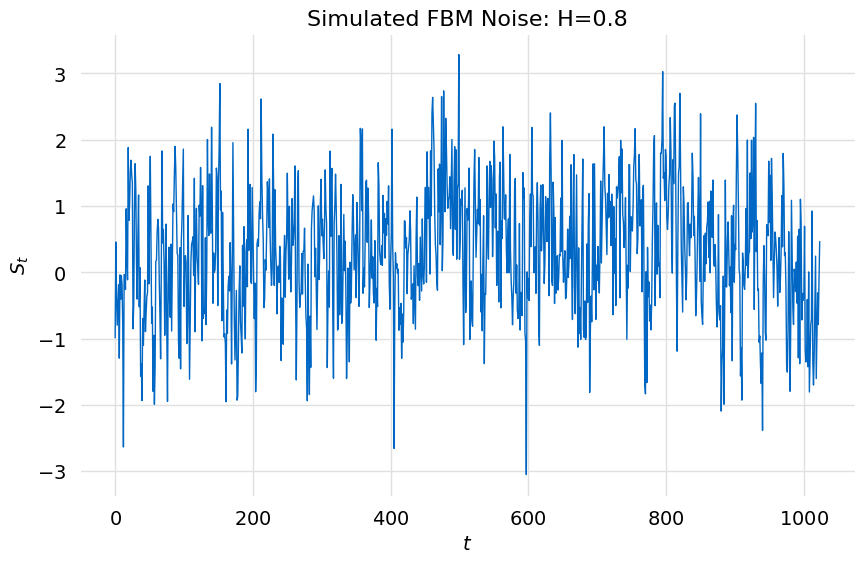

In [5]:
H = 0.8
t, fbm_noise = fbm.create_noise_fft_source(H=H, npts=npts)

title = f"Simulated FBM Noise: H={H}"
curve(fbm_noise, lw=1, title=title, xlabel=r"$t$", ylabel=r"$S_t$")

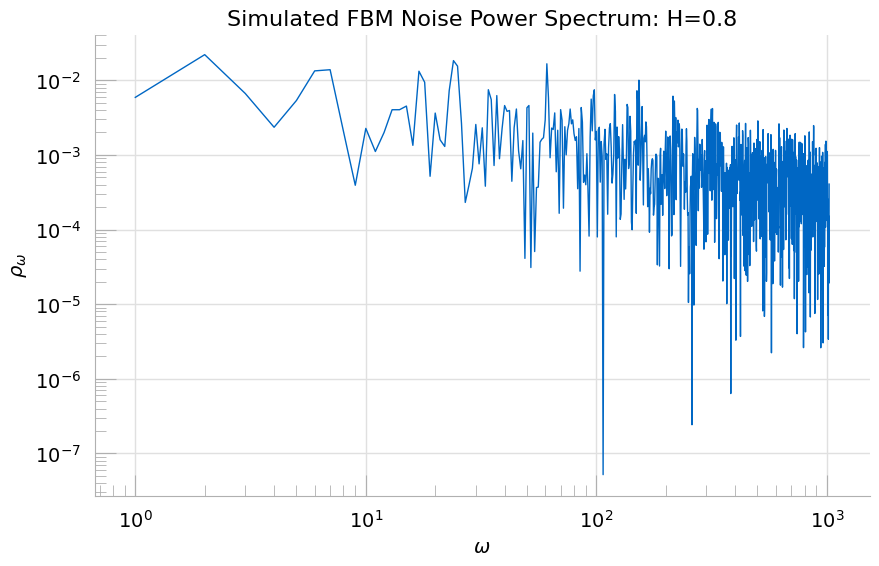

In [6]:
freq, ps = stats.compute_pspec(t, fbm_noise)

title = f"Simulated FBM Noise Power Spectrum: H={H}"
curve(ps, freq, lw=1, title=title, xlabel=r"$\omega$", ylabel=r"$\rho_\omega$", plot_axis_type=PlotType.LOG)

In [9]:
result, result_model = fbm.compute_H_estimate_periodogram(freq, ps)
result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.166
Model:                            OLS   Adj. R-squared:                  0.165
Method:                 Least Squares   F-statistic:                     202.8
Date:                Sun, 03 Sep 2023   Prob (F-statistic):           4.14e-42
Time:                        17:46:10   Log-Likelihood:                -907.34
No. Observations:                1023   AIC:                             1819.
Df Residuals:                    1021   BIC:                             1829.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -1.8057      0.112    -16.085      0.000      -2.026      -1.585
x1            -0.6119      0.043    -14.241      0.000      -0.696      -0.528
==============================================================================
Omnibus:                      310.334   Durbin-Watson:                   1.464
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             1165.817
Skew:                          -1.417   Prob(JB):                    7.01e-254
Kurtosis:                       7.395   Cond. No.                         18.2
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [10]:
print(result_model.to_json(pretty=True))

{
   "est_model": "OLS_SING_VAR",
   "const": {
      "est": -1.8056875472564984,
      "err": 0.11225835262714025,
      "est_label": null,
      "err_label": null,
      "row": 0,
      "column": 0,
      "order": 1,
      "est_id": "48e512b8-b4bb-4337-9a02-341806610c6e",
      "param_type": "OLS_CONST"
   },
   "param": {
      "est": -0.6118741244125955,
      "err": 0.04296614186966943,
      "est_label": null,
      "err_label": null,
      "row": 0,
      "column": 0,
      "order": 1,
      "est_id": "48e512b8-b4bb-4337-9a02-341806610c6e",
      "param_type": "OLS_PARAM"
   },
   "r2": 0.16571446873897921,
   "transform": {
      "model": "$C\\omega^{1 - 2H}$",
      "param": {
         "est": 0.8059370622062978,
         "err": 0.021483070934834717,
         "est_label": "$\\hat{\u0397}$",
         "err_label": "$\\sigma_{\\hat{\u0397}}$",
         "row": 0,
         "column": 0,
         "order": 0,
         "est_id": "48e512b8-b4bb-4337-9a02-341806610c6e",
         "param_ty

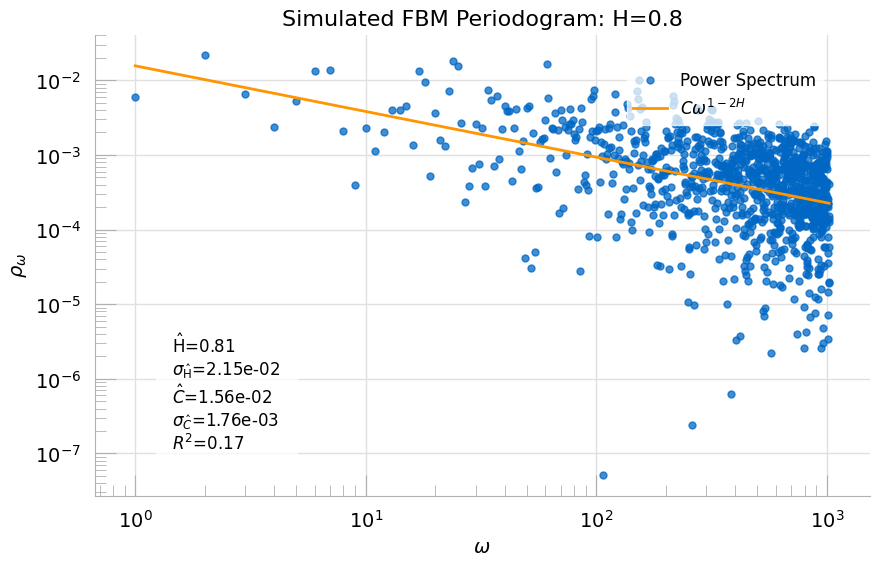

In [11]:
periodogram(ps, result_model, freq, title=f"Simulated FBM Periodogram: H={H}")

## Power Spectrum Simulation H=0.3

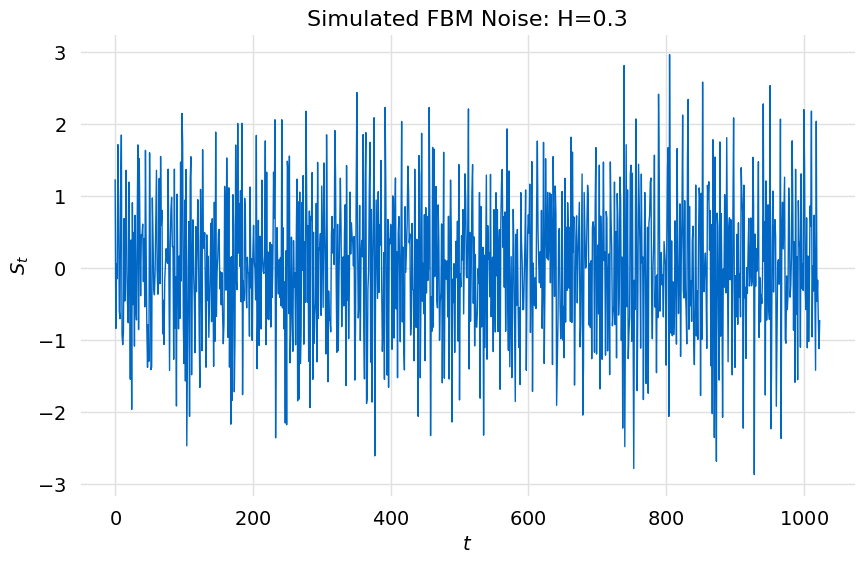

In [12]:
H = 0.3
t, fbm_noise = fbm.create_noise_fft_source(H=H, npts=npts)

title = f"Simulated FBM Noise: H={H}"
curve(fbm_noise, lw=1, title=title, xlabel=r"$t$", ylabel=r"$S_t$")

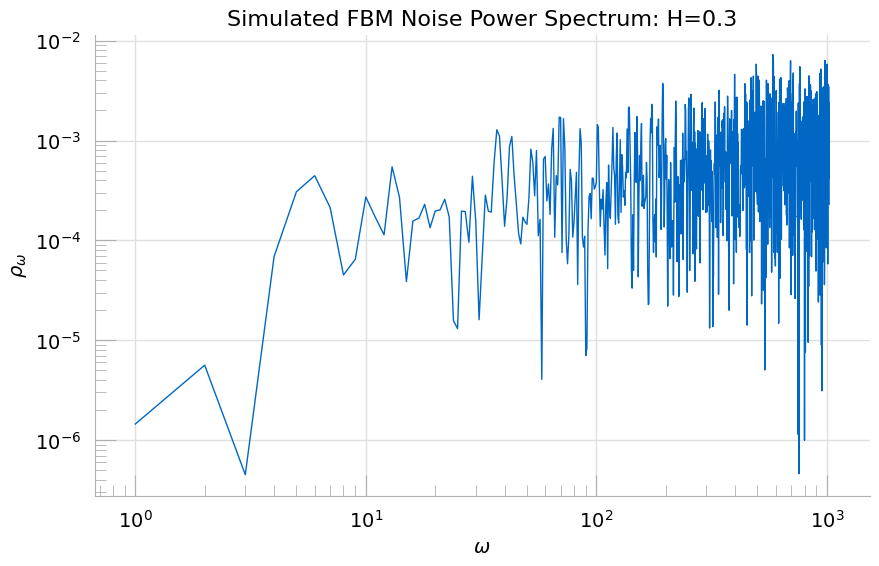

In [13]:
freq, ps = stats.compute_pspec(t, fbm_noise)

title = f"Simulated FBM Noise Power Spectrum: H={H}"
curve(ps, freq, lw=1, title=title, xlabel=r"$\omega$", ylabel=r"$\rho_\omega$", plot_axis_type=PlotType.LOG)

In [15]:
result, result_model = fbm.compute_H_estimate_periodogram(freq, ps)
result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.104
Model:                            OLS   Adj. R-squared:                  0.103
Method:                 Least Squares   F-statistic:                     118.1
Date:                Sun, 03 Sep 2023   Prob (F-statistic):           4.22e-26
Time:                        17:49:50   Log-Likelihood:                -852.83
No. Observations:                1023   AIC:                             1710.
Df Residuals:                    1021   BIC:                             1720.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -4.4359      0.106    -41.678      0.000      -4.645      -4.227
x1             0.4426      0.041     10.866      0.000       0.363       0.523
==============================================================================
Omnibus:                      221.088   Durbin-Watson:                   1.427
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              533.956
Skew:                          -1.151   Prob(JB):                    1.13e-116
Kurtosis:                       5.689   Cond. No.                         18.2
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [16]:
print(result_model.to_json(pretty=True))

{
   "est_model": "OLS_SING_VAR",
   "const": {
      "est": -4.435912028001886,
      "err": 0.10643280143842548,
      "est_label": null,
      "err_label": null,
      "row": 0,
      "column": 0,
      "order": 1,
      "est_id": "a0bc5377-2b76-4f44-9b22-9fd6b641ef5b",
      "param_type": "OLS_CONST"
   },
   "param": {
      "est": 0.44263581171740896,
      "err": 0.040736450688696,
      "est_label": null,
      "err_label": null,
      "row": 0,
      "column": 0,
      "order": 1,
      "est_id": "a0bc5377-2b76-4f44-9b22-9fd6b641ef5b",
      "param_type": "OLS_PARAM"
   },
   "r2": 0.10365198875127613,
   "transform": {
      "model": "$C\\omega^{1 - 2H}$",
      "param": {
         "est": 0.2786820941412955,
         "err": 0.020368225344348,
         "est_label": "$\\hat{\u0397}$",
         "err_label": "$\\sigma_{\\hat{\u0397}}$",
         "row": 0,
         "column": 0,
         "order": 0,
         "est_id": "a0bc5377-2b76-4f44-9b22-9fd6b641ef5b",
         "param_type": "

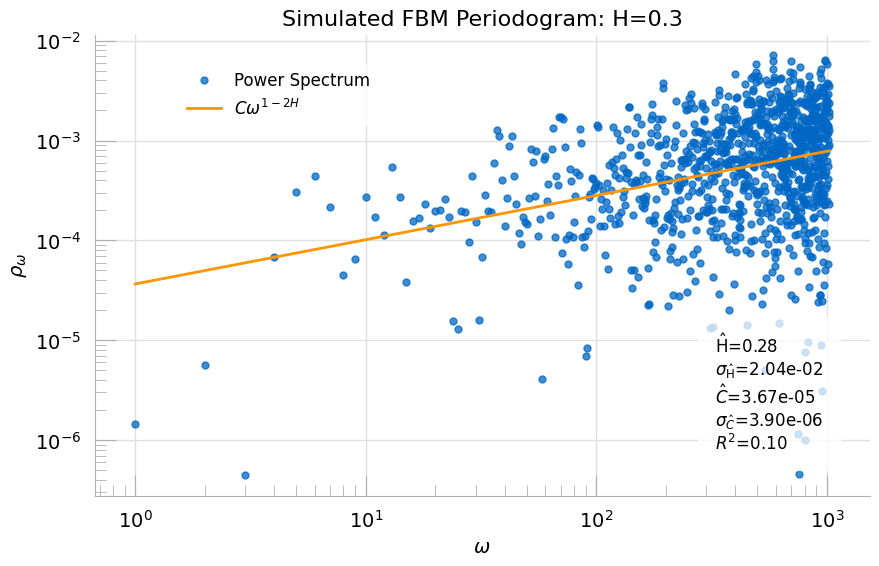

In [17]:
periodogram(ps, result_model, freq, title=f"Simulated FBM Periodogram: H={H}")